<a href="https://colab.research.google.com/github/Shahana023/cse-resources/blob/main/FGSM_VS_PGD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LIBRARIES

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

Dataset

In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 42.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.73MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


implemnt CNN

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)

        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):

        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))

        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Create Model

In [ ]:
model = SimpleCNN()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

train the model

In [ ]:
epochs = 3

for epoch in range(epochs):

    running_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 141.9092
Epoch 2, Loss: 39.9558
Epoch 3, Loss: 24.0168


Check Accuracy

In [ ]:
total = 0
correct = 0
with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

print("Normal Accuracy:", 100 * correct / total)

Normal Accuracy: 98.93


FGSM Attack

In [ ]:
def fgsm_attack(image, epsilon, data_grad):

    sign_data_grad = data_grad.sign()

    perturbed_image = image + epsilon * sign_data_grad

    perturbed_image = torch.clamp(perturbed_image, 0, 1)

    return perturbed_image

fgsmtrain

In [18]:
epsilon = 0.1

correct = 0
adv_examples = []

for images, labels in test_loader:

    images.requires_grad = True

    outputs = model(images)

    loss = criterion(outputs, labels)

    model.zero_grad()

    loss.backward()

    data_grad = images.grad.data

    perturbed_data = fgsm_attack(images, epsilon, data_grad)

    output = model(perturbed_data)

    _, final_pred = torch.max(output.data, 1)

    if final_pred.item() == labels.item():
        correct += 1

accuracy = correct / len(test_loader)

print("Accuracy under FGSM attack:", accuracy * 100)

Accuracy under FGSM attack: 89.07000000000001


PGD

In [ ]:
def pgd_attack(model, images, labels, epsilon, alpha, iters):

    original_images = images.clone().detach()

    for i in range(iters):

        images.requires_grad = True

        outputs = model(images)

        loss = criterion(outputs, labels)

        model.zero_grad()

        loss.backward()

        adv_images = images + alpha * images.grad.sign()

        eta = torch.clamp(
            adv_images - original_images,
            min=-epsilon,
            max=epsilon
        )

        images = torch.clamp(original_images + eta, 0, 1).detach()

    return images

PGD attack

In [19]:
epsilon = 0.1
alpha = 0.01
iters = 20

correct = 0

for images, labels in test_loader:

    adv_images = pgd_attack(
        model,
        images,
        labels,
        epsilon,
        alpha,
        iters
    )

    outputs = model(adv_images)

    _, predicted = torch.max(outputs.data, 1)

    correct += (predicted == labels).sum().item()

accuracy = correct / len(test_loader)

print("PGD Attack Accuracy:", accuracy * 100)

PGD Attack Accuracy: 82.08


In [21]:
normal_accuracy = 98.93

fgsm_accuracy = 89.07

pgd_accuracy = 82.08

print("Normal CNN Accuracy:", normal_accuracy)

print("FGSM Attack Accuracy:", fgsm_accuracy)

print("PGD Attack Accuracy:", pgd_accuracy)

Normal CNN Accuracy: 98.93
FGSM Attack Accuracy: 89.07
PGD Attack Accuracy: 82.08


comparison

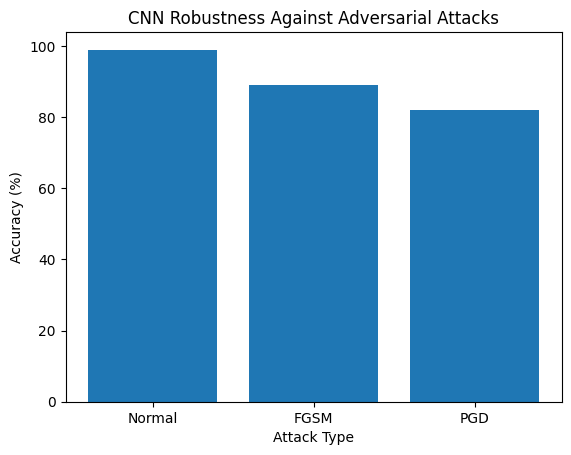

In [22]:
attacks = ['Normal', 'FGSM', 'PGD']

accuracies = [
    normal_accuracy,
    fgsm_accuracy,
    pgd_accuracy
]

plt.bar(attacks, accuracies)

plt.xlabel("Attack Type")

plt.ylabel("Accuracy (%)")

plt.title("CNN Robustness Against Adversarial Attacks")

plt.show()

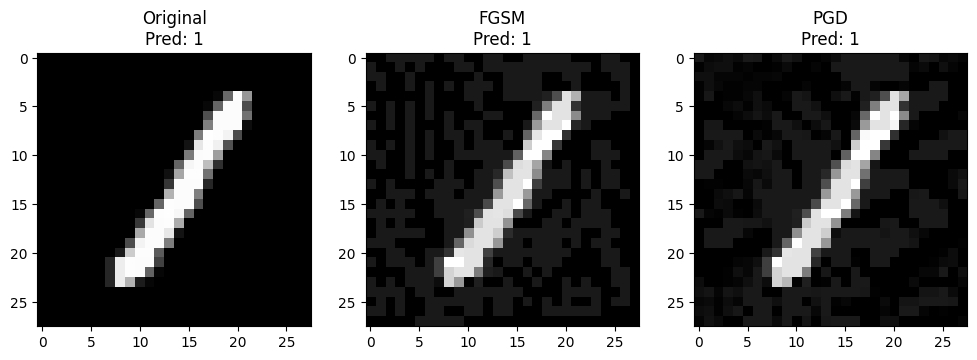

In [23]:
images, labels = next(iter(test_loader))

# -------- FGSM --------

images.requires_grad = True

outputs = model(images)

loss = criterion(outputs, labels)

model.zero_grad()

loss.backward()

data_grad = images.grad.data

fgsm_image = fgsm_attack(images, 0.1, data_grad)

# -------- PGD --------

pgd_image = pgd_attack(
    model,
    images,
    labels,
    epsilon=0.1,
    alpha=0.01,
    iters=20
)

# -------- Predictions --------

orig_output = model(images)

fgsm_output = model(fgsm_image)

pgd_output = model(pgd_image)

_, orig_pred = torch.max(orig_output.data, 1)

_, fgsm_pred = torch.max(fgsm_output.data, 1)

_, pgd_pred = torch.max(pgd_output.data, 1)

# -------- Plot --------

fig, ax = plt.subplots(1,3, figsize=(12,4))

ax[0].imshow(images[0].squeeze().detach(), cmap='gray')
ax[0].set_title(f"Original\nPred: {orig_pred[0].item()}")

ax[1].imshow(fgsm_image[0].squeeze().detach(), cmap='gray')
ax[1].set_title(f"FGSM\nPred: {fgsm_pred[0].item()}")

ax[2].imshow(pgd_image[0].squeeze().detach(), cmap='gray')
ax[2].set_title(f"PGD\nPred: {pgd_pred[0].item()}")

plt.show()